<a href="https://colab.research.google.com/github/ruveydakarakoyun/APTOS-2019/blob/main/aptos_2019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Veri Yükleme ve Kütüphaneleri Yükleme

In [3]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU kullanılabilir mi?:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
GPU kullanılabilir mi?: True


In [14]:
# Google Cloud Kimlik Doğrulama
from google.colab import auth
auth.authenticate_user()

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from google.cloud import bigquery, storage

# Proje ve Bucket bilgilerin (Kendi Project ID'ni yaz)
PROJECT_ID = "datascience-project-id"  # GCP ekranındaki Project ID
BUCKET_NAME = "aptos2019-retina-images" # Cloud Storage bucket adın

print("✅ Bağlantı ve kütüphaneler hazır!")

✅ Bağlantı ve kütüphaneler hazır!


###BigQuery'den Tabloları Çekme

In [15]:
from google.cloud import bigquery, storage

# ==============================================================================
# PROJE GENEL YAPILANDIRMASI (CONFIG)
# ==============================================================================
GCP_PROJECT_ID = "datascientis"
GCS_BUCKET_NAME = "aptos2019-retina-images"
BIGQUERY_DATASET = "APTOS_2019"

# Bucket içindeki klasör yolları (Prefix)
PATH_PREFIXES = {
    "train": "aptos_train_images/",
    "valid": "aptos_valid_images/",
    "test":  "aptos_test_images/"
}

# BigQuery tablo yolları
BQ_TABLES = {
    "train": f"{GCP_PROJECT_ID}.{BIGQUERY_DATASET}.aptos_train",
    "valid": f"{GCP_PROJECT_ID}.{BIGQUERY_DATASET}.aptos_valid",
    "test":  f"{GCP_PROJECT_ID}.{BIGQUERY_DATASET}.aptos_test"
}

# ==============================================================================
# BİGQUERY'DEN VERİLERİ ÇEKME
# ==============================================================================
bq_client = bigquery.Client(project=GCP_PROJECT_ID)

# image_file kolonunu da sorguya ekledik
query_train = f"SELECT id_code, diagnosis, image_file FROM `{BQ_TABLES['train']}`"
query_valid = f"SELECT id_code, diagnosis, image_file FROM `{BQ_TABLES['valid']}`"
query_test  = f"SELECT id_code, diagnosis, image_file FROM `{BQ_TABLES['test']}`"

df_train = bq_client.query(query_train).to_dataframe()
df_valid = bq_client.query(query_valid).to_dataframe()
df_test  = bq_client.query(query_test).to_dataframe()

print(f"📊 Train Veri Sayısı : {len(df_train)}")
print(f"📊 Valid Veri Sayısı : {len(df_valid)}")
print(f"📊 Test Veri Sayısı  : {len(df_test)}")

📊 Train Veri Sayısı : 2930
📊 Valid Veri Sayısı : 366
📊 Test Veri Sayısı  : 366


In [16]:
import io
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

class APTOSDataset(Dataset):
    def __init__(self, df, bucket_name, project_id, transform=None):
        self.df = df
        self.transform = transform
        storage_client = storage.Client(project=project_id)
        self.bucket = storage_client.bucket(bucket_name)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Resim adını tablonuzdaki image_file kolonundan alıyoruz
        img_name = row['image_file'] if 'image_file' in row and pd.notnull(row['image_file']) else f"{row['id_code']}.png"
        label = int(row['diagnosis']) if 'diagnosis' in row and pd.notnull(row['diagnosis']) else -1

        # Cloud Storage'dan dosyayı indirmeden doğrudan akış (stream) olarak okuma
        blob = self.bucket.blob(img_name)
        image_bytes = blob.download_as_bytes()

        # Görüntüyü PIL Image formatına çevirme
        img = Image.open(io.BytesIO(image_bytes)).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)

###Dataframe'leri ve Transform'ları Ayırma

In [17]:
# Transform tanımları
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dataset ve DataLoader nesneleri
train_dataset = APTOSDataset(df_train, BUCKET_NAME, PROJECT_ID, transform=train_transform)
valid_dataset = APTOSDataset(df_valid, BUCKET_NAME, PROJECT_ID, transform=eval_transform)
test_dataset  = APTOSDataset(df_test,  BUCKET_NAME, PROJECT_ID, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print("✅ Bütün sistem bağlandı, fotoğraflar indirilmeden Cloud üzerinden okunacak!")

✅ Bütün sistem bağlandı, fotoğraflar indirilmeden Cloud üzerinden okunacak!


#EDA

###Sınıf dağılımı (Evre 0 - Evre 4 kaçar adet?) grafikleri ve Sınıf dengesizliği oranları


📊 Train Sınıf Dağılımı


,Evre,Sınıf,Görüntü Sayısı,Yüzde (%)
0,0,No DR,1434,48.94
1,1,Mild,300,10.24
2,2,Moderate,808,27.58
3,3,Severe,154,5.26
4,4,Proliferative DR,234,7.99


En fazla görüntü: Evre 0 → 1434
En az görüntü: Evre 3 → 154
Sınıf dengesizlik oranı (Max / Min): 9.31


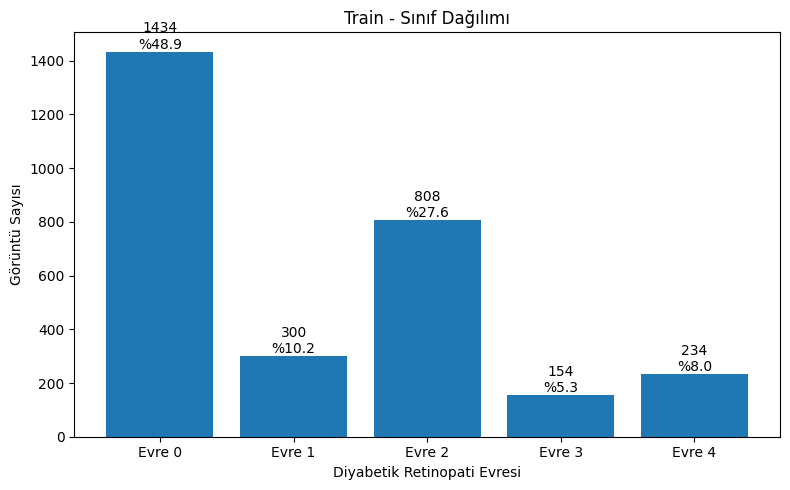


📊 Validation Sınıf Dağılımı


,Evre,Sınıf,Görüntü Sayısı,Yüzde (%)
0,0,No DR,172,46.99
1,1,Mild,40,10.93
2,2,Moderate,104,28.42
3,3,Severe,22,6.01
4,4,Proliferative DR,28,7.65


En fazla görüntü: Evre 0 → 172
En az görüntü: Evre 3 → 22
Sınıf dengesizlik oranı (Max / Min): 7.82


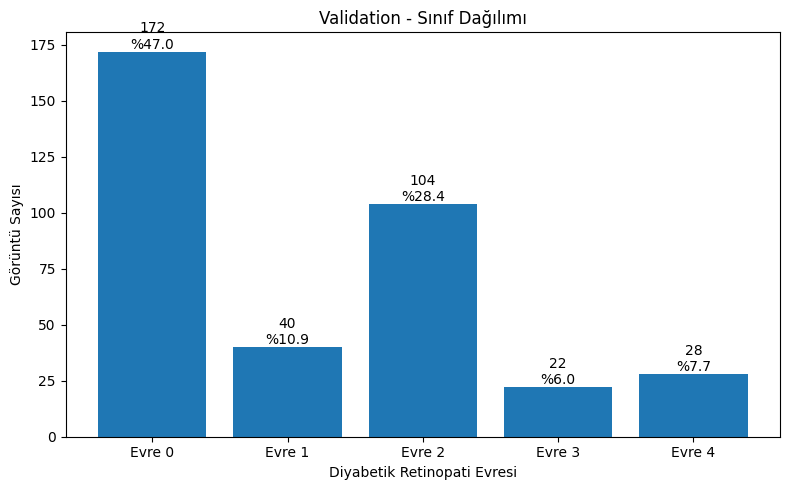


📊 Test Sınıf Dağılımı


,Evre,Sınıf,Görüntü Sayısı,Yüzde (%)
0,0,No DR,199,54.37
1,1,Mild,30,8.2
2,2,Moderate,87,23.77
3,3,Severe,17,4.64
4,4,Proliferative DR,33,9.02


En fazla görüntü: Evre 0 → 199
En az görüntü: Evre 3 → 17
Sınıf dengesizlik oranı (Max / Min): 11.71


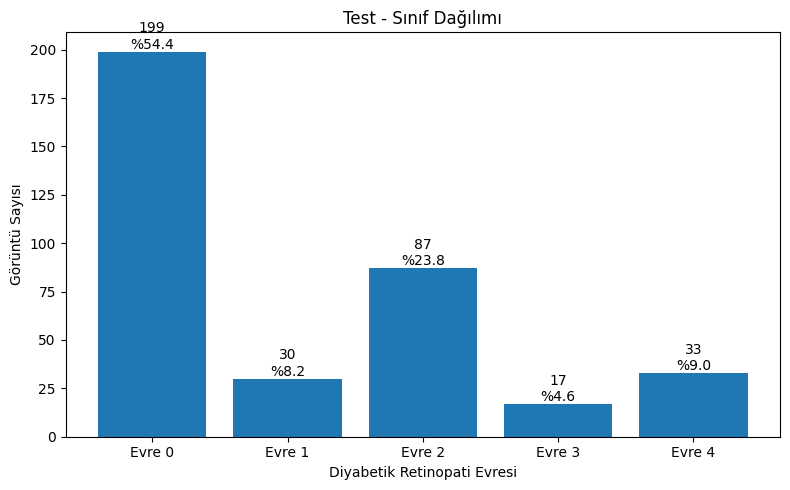

In [18]:
# Sınıf dağılımı
# Sınıf isimleri
class_names = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR"
}

datasets = {
    "Train": df_train,
    "Validation": df_valid,
    "Test": df_test
}

for dataset_name, df in datasets.items():

    # Her sınıftaki görüntü sayısı
    counts = (
        df["diagnosis"]
        .value_counts()
        .reindex(range(5), fill_value=0)
        .sort_index()
    )

    # Yüzdelik dağılım
    percentages = (counts / counts.sum()) * 100

    # Sonuç tablosu
    distribution_table = pd.DataFrame({
        "Evre": counts.index,
        "Sınıf": [class_names[i] for i in counts.index],
        "Görüntü Sayısı": counts.values,
        "Yüzde (%)": percentages.round(2).values
    })

    print(f"\n📊 {dataset_name} Sınıf Dağılımı")
    display(distribution_table)

    # Sınıf dengesizliği
    non_zero_counts = counts[counts > 0]

    max_count = non_zero_counts.max()
    min_count = non_zero_counts.min()

    imbalance_ratio = max_count / min_count

    print(f"En fazla görüntü: Evre {non_zero_counts.idxmax()} → {max_count}")
    print(f"En az görüntü: Evre {non_zero_counts.idxmin()} → {min_count}")
    print(f"Sınıf dengesizlik oranı (Max / Min): {imbalance_ratio:.2f}")

    # Grafik
    plt.figure(figsize=(8, 5))

    bars = plt.bar(
        [f"Evre {i}" for i in counts.index],
        counts.values
    )

    plt.title(f"{dataset_name} - Sınıf Dağılımı")
    plt.xlabel("Diyabetik Retinopati Evresi")
    plt.ylabel("Görüntü Sayısı")

    for bar, count, percentage in zip(
        bars, counts.values, percentages.values
    ):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{count}\n%{percentage:.1f}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

 ### Ham retina resimlerinin piksel boyutları, çözünürlükleri ve renk kanalları (RGB/Grayscale) kontrol edilir.

In [ ]:
# Ham retina resimlerinin piksel boyutları, çözünürlükleri ve renk kanalları
import io
from tqdm.auto import tqdm

# Cloud Storage bağlantısı
storage_client = storage.Client(project=PROJECT_ID)
bucket = storage_client.bucket(BUCKET_NAME)

# Train, Validation ve Test verilerini birleştir
all_df = pd.concat([
    df_train.assign(split="Train"),
    df_valid.assign(split="Validation"),
    df_test.assign(split="Test")
], ignore_index=True)

image_properties = []

for _, row in tqdm(
    all_df.iterrows(),
    total=len(all_df),
    desc="Görüntüler inceleniyor"
):

    # GCS'deki görüntü adı
    image_name = str(row["id_code"])

    if not image_name.endswith(".png"):
        image_name += ".png"

    try:
        # Görüntüyü GCS'den oku
        blob = bucket.blob(image_name)
        image_bytes = blob.download_as_bytes()

        img = Image.open(io.BytesIO(image_bytes))

        # Görüntü özellikleri
        width, height = img.size
        color_mode = img.mode
        channels = len(img.getbands())

        image_properties.append({
            "id_code": row["id_code"],
            "split": row["split"],
            "width": width,
            "height": height,
            "resolution": f"{width}x{height}",
            "color_mode": color_mode,
            "channels": channels
        })

    except Exception as e:

        image_properties.append({
            "id_code": row["id_code"],
            "split": row["split"],
            "width": None,
            "height": None,
            "resolution": None,
            "color_mode": None,
            "channels": None
        })


# Sonuçları DataFrame'e çevir
image_properties_df = pd.DataFrame(image_properties)

print("✅ Ham görüntü özellikleri incelendi.")
print(f"Toplam görüntü sayısı: {len(image_properties_df)}")

display(image_properties_df.head())

Görüntüler inceleniyor:   0%|          | 0/3662 [00:00<?, ?it/s]

###Veri Temizleme ve Kalite Kontrol Betiği

In [8]:
import io
import numpy as np
from PIL import Image, ImageStat
from google.cloud import storage
from tqdm import tqdm

def check_dataset_quality(df, bucket_name, project_id, brightness_threshold=15.0):
    """
    Cloud Storage'daki görselleri kontrol eder:
    - Bozuk / Açılmayan resimleri bulur.
    - Aşırı karanlık (ortalama piksel değeri eşik değerinin altındaki) resimleri bulur.
    """
    storage_client = storage.Client(project=project_id)
    bucket = storage_client.bucket(bucket_name)

    corrupted_images = []
    too_dark_images = []
    valid_indices = []

    print("🔍 Görüntü kalitesi ve bütünlüğü kontrol ediliyor...\n")

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        img_name = row['image_file'] if 'image_file' in row and pd.notnull(row['image_file']) else f"{row['id_code']}.png"

        try:
            # 1. Cloud Storage'dan dosyayı çekme
            blob = bucket.blob(img_name)
            image_bytes = blob.download_as_bytes()

            # 2. Resmi açma denemesi (Bozuk dosya kontrolü)
            img = Image.open(io.BytesIO(image_bytes)).convert("RGB")

            # 3. Parlaklık kontrolü (Aşırı karanlık resim tespiti)
            # Gri seviyeye çevirip ortalama piksel değerini (0-255 arası) hesaplıyoruz
            stat = ImageStat.Stat(img.convert("L"))
            mean_brightness = stat.mean[0]

            if mean_brightness < brightness_threshold:
                too_dark_images.append({'id_code': row['id_code'], 'image_file': img_name, 'brightness': mean_brightness})
            else:
                valid_indices.append(idx)

        except Exception as e:
            # Okunamayan veya bozuk resimleri yakalama
            corrupted_images.append({'id_code': row['id_code'], 'image_file': img_name, 'error': str(e)})

    # --- RAPORLAMA ---
    print("\n" + "="*40)
    print("📋 KONTROL SONUÇLARI RAPORU")
    print("="*40)
    print(f"✅ Sağlam ve Geçerli Görsel Sayısı : {len(valid_indices)}")
    print(f"❌ Bozuk / Açılmayan Görsel Sayısı: {len(corrupted_images)}")
    print(f"⚠️  Aşırı Karanlık Görsel Sayısı  : {len(too_dark_images)}")

    return valid_indices, corrupted_images, too_dark_images

# --- BETİĞİ ÇALIŞTIRMA ---
# Train veri setiniz üzerinde testi başlatın:
valid_idx, corrupted_list, dark_list = check_dataset_quality(
    df=df_train,
    bucket_name=BUCKET_NAME,
    project_id=PROJECT_ID,
    brightness_threshold=12.0  # Ortalama piksel değeri 12'nin altındakileri uyarır
)

🔍 Görüntü kalitesi ve bütünlüğü kontrol ediliyor...



100%|██████████| 2930/2930 [17:50<00:00,  2.74it/s]


📋 KONTROL SONUÇLARI RAPORU
✅ Sağlam ve Geçerli Görsel Sayısı : 0
❌ Bozuk / Açılmayan Görsel Sayısı: 2930
⚠️  Aşırı Karanlık Görsel Sayısı  : 0


###Bozuk / Açılmayan Görsel Sayısı: 2930'un neden olduğunu sorgulama

In [11]:
import io
from PIL import Image
from google.cloud import storage

storage_client = storage.Client(project=PROJECT_ID)
bucket = storage_client.bucket(BUCKET_NAME)

# İlk 5 resmi test edip hatanın gerçek sebebini ekrana basalım
for idx, row in df_train.head(5).iterrows():
    # BigQuery'deki isme göre dosya yolu
    img_name = row['image_file'] if 'image_file' in row and pd.notnull(row['image_file']) else f"{row['id_code']}.png"

    print(f"Aranan Dosya Yolu: '{img_name}'")

    try:
        blob = bucket.blob(img_name)
        image_bytes = blob.download_as_bytes()
        img = Image.open(io.BytesIO(image_bytes))
        print(" -> ✅ BAŞARILI: Resim okundu!\n")
    except Exception as e:
        print(f" -> ❌ HATA DETAYI: {e}\n")

Aranan Dosya Yolu: '1f4fb37e0854.png'
 -> ❌ HATA DETAYI: 404 GET https://storage.googleapis.com/download/storage/v1/b/aptos2019-retina-images/o/1f4fb37e0854.png?alt=media: No such object: aptos2019-retina-images/1f4fb37e0854.png: ('Request failed with status code', 404, 'Expected one of', <HTTPStatus.OK: 200>, <HTTPStatus.PARTIAL_CONTENT: 206>)

Aranan Dosya Yolu: '3079490a4b9c.png'
 -> ❌ HATA DETAYI: 404 GET https://storage.googleapis.com/download/storage/v1/b/aptos2019-retina-images/o/3079490a4b9c.png?alt=media: No such object: aptos2019-retina-images/3079490a4b9c.png: ('Request failed with status code', 404, 'Expected one of', <HTTPStatus.OK: 200>, <HTTPStatus.PARTIAL_CONTENT: 206>)

Aranan Dosya Yolu: '3286073a976e.png'
 -> ❌ HATA DETAYI: 404 GET https://storage.googleapis.com/download/storage/v1/b/aptos2019-retina-images/o/3286073a976e.png?alt=media: No such object: aptos2019-retina-images/3286073a976e.png: ('Request failed with status code', 404, 'Expected one of', <HTTPStatus.OK

In [12]:
# Bucket içindeki ilk 5 dosyanın tam yolunu listeleyelim
blobs = list(storage_client.list_blobs(BUCKET_NAME, max_results=5))

print("📁 BUCKET İÇİNDEKİ GERÇEK DOSYA YOLLARI:")
for blob in blobs:
    print(blob.name)

📁 BUCKET İÇİNDEKİ GERÇEK DOSYA YOLLARI:
aptos_test_images/
aptos_test_images/e4dcca36ceb4.png
aptos_test_images/e4e343eaae2a.png
aptos_test_images/e4f12411fd85.png
aptos_test_images/e50b0174690d.png


###Göz etrafındaki siyah boşlukları otomatik kesen Auto-Crop uygulama.

In [ ]:
import io
import cv2
import numpy as np
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader

# 1. AUTO-CROP FONKSİYONU
def crop_image_from_gray(img, tol=7):
    if img.ndim == 2:
        mask = img > tol
        return img[np.ix_(mask.any(1), mask.any(0))]
    elif img.ndim == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img > tol
        check_shape = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))].shape
        if check_shape[0] == 0 or check_shape[1] == 0:
            return img
        else:
            img1 = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))]
            img2 = img[:, :, 1][np.ix_(mask.any(1), mask.any(0))]
            img3 = img[:, :, 2][np.ix_(mask.any(1), mask.any(0))]
            return np.stack([img1, img2, img3], axis=-1)

# 2. ENTEGRE EDİLMİŞ DATASET SINIFI
class APTOSDataset(Dataset):
    def __init__(self, df, bucket_name, project_id, transform=None):
        self.df = df
        self.transform = transform
        storage_client = storage.Client(project=project_id)
        self.bucket = storage_client.bucket(bucket_name)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['image_file'] if 'image_file' in row and pd.notnull(row['image_file']) else f"{row['id_code']}.png"
        label = int(row['diagnosis']) if 'diagnosis' in row and pd.notnull(row['diagnosis']) else -1

        # Cloud'dan çekme
        blob = self.bucket.blob(img_name)
        image_bytes = blob.download_as_bytes()

        # PIL -> NumPy (Auto-Crop için) -> PIL
        img_pil = Image.open(io.BytesIO(image_bytes)).convert("RGB")
        img_np = np.array(img_pil)
        img_cropped = crop_image_from_gray(img_np, tol=7)
        img_final = Image.fromarray(img_cropped)

        # ResNet/EfficientNet için Resize & Transform
        if self.transform:
            img_tensor = self.transform(img_final)

        return img_tensor, torch.tensor(label, dtype=torch.long)